# Proyecto Final — Analítica de Datos

**Universidad Iberoamericana · Primavera 2026**
**Materia:** Analítica de Datos
**Profesor:** Rodrigo Cárdenas Domínguez
**Alumnos:** Hector Raul Becerril Villamil · Elena Carolina Sánchez Araiza

---

### Objetivo del notebook

A partir del dataset *Diabetes 130-Hospitals* (UCI) se responden tres preguntas siguiendo el flujo metodológico revisado en clase:

1. **¿Qué pacientes regresan al hospital antes de 30 días?** → regresión **logística**
2. **¿Cuántas veces se interna un paciente?** → regresión **Poisson** y **Binomial Negativa**
3. **¿Cuánto duran las estancias?** → regresión **Gamma** con liga log

El orden es el mismo en cada sección: primero se observa la forma de los datos, después se aplican las pruebas estadísticas pertinentes y, finalmente, se ajusta el modelo con la familia de distribución sugerida por el análisis exploratorio.


## 1. Configuración

Los imports se agrupan al inicio para mantener el notebook ordenado. Se utiliza `statsmodels` (en vez de `sklearn`) porque entrega p-valores y errores estándar listos para reportar.

In [1]:
# librerías de manejo de datos
import pandas as pd
import numpy as np

# gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# estadística e inferencia
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# evaluación del modelo logístico
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')   # statsmodels imprime muchos warnings; se silencian

# estilo visual consistente
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# semilla fija para reproducibilidad
SEMILLA = 42
RUTA_DATOS = 'fuente_codex/diabetic_data.csv'


## 2. Carga de datos

El archivo proviene del repositorio UCI. Una particularidad del formato: los valores faltantes están codificados como `?` en lugar de NaN. Se gestionan desde la lectura para evitar reemplazos posteriores.

In [2]:
# na_values=['?'] convierte todos los '?' a NaN automáticamente
df_raw = pd.read_csv(RUTA_DATOS, na_values=['?'])

print(f'Filas: {df_raw.shape[0]:,}   Columnas: {df_raw.shape[1]}')
df_raw.head(3)


Filas: 101,766   Columnas: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## 3. Auditoría de valores faltantes

Antes de la limpieza se examina cuánto falta en cada columna y dónde se concentra.

In [3]:
# % de NaN por columna, ordenado de más a menos faltante
faltantes = df_raw.isna().mean().sort_values(ascending=False)
faltantes[faltantes > 0].mul(100).round(2).to_frame('pct_faltante')


,pct_faltante
weight,96.86
max_glu_serum,94.75
A1Cresult,83.28
medical_specialty,49.08
payer_code,39.56
race,2.23
diag_3,1.40
diag_2,0.35
diag_1,0.02


### ¿Por qué NO se utiliza imputación múltiple (MICE)?

En la clase se vio MICE como técnica adecuada para datos **MAR** (faltantes al azar dado lo observado). En este dataset los faltantes parecen comportarse de manera distinta:

| Variable | % faltante | Por qué imputar es discutible |
|---|---|---|
| `weight` | ~97% | Casi nunca se mide. No hay información suficiente para reconstruirla. |
| `medical_specialty` | ~49% | Falta cuando el ingreso *no fue asignado a un especialista* — la ausencia parece ser información, no error. |
| `payer_code` | ~40% | Falta para auto-pago o "no aplica" — también informativa. |
| `race` | ~2% | Faltante bajo, no claramente MAR ni MNAR. Se trata como categoría. |

No se declara formalmente que sean **MNAR** (eso requiere evidencia o un modelo del mecanismo de pérdida). Se adopta la siguiente postura: en lugar de fabricar valores con MICE, se permite que la ausencia se comporte como categoría observable (`'Desconocido'`).

**Tratamiento aplicado:**
1. Se elimina `weight` (97% vacía).
2. Se convierte `?` a `NaN` real.
3. Para categóricas con faltantes informativos se asigna la categoría `'Desconocido'`.
4. Se aplica `dropna()` *únicamente* sobre las columnas que entran a cada modelo.

**Validación empírica del supuesto de faltante informativo.** A continuación se compara la tasa de readmisión entre pacientes con `medical_specialty == 'Desconocido'` y los que sí tienen especialista asignado. Si las tasas difieren de forma material, queda respaldada la decisión de tratar la ausencia como categoría en lugar de imputarla.

In [4]:
# Validación empírica del supuesto de faltante informativo en medical_specialty
# Se usa df_raw porque conserva la marca original de NaN (sin recodificar a 'Desconocido')
mask_desconocido = df_raw['medical_specialty'].isna()
mask_conocido    = ~mask_desconocido

# tasa de readmisión a 30 días en cada subgrupo
readm_30 = (df_raw['readmitted'] == '<30').astype(int)

tasa_desconocido = readm_30[mask_desconocido].mean() * 100
tasa_conocido    = readm_30[mask_conocido].mean()    * 100
n_desc, n_con    = mask_desconocido.sum(), mask_conocido.sum()
diferencia       = tasa_desconocido - tasa_conocido

# prueba chi² para significancia
from scipy.stats import chi2_contingency
tabla = pd.crosstab(mask_desconocido, readm_30)
chi2, p_val, _, _ = chi2_contingency(tabla)

print(f"Pacientes con medical_specialty desconocida: {n_desc:,}")
print(f"  Tasa de readmisión a 30 días:              {tasa_desconocido:.2f}%")
print(f"\nPacientes con medical_specialty conocida:  {n_con:,}")
print(f"  Tasa de readmisión a 30 días:              {tasa_conocido:.2f}%")
print(f"\nDiferencia absoluta: {diferencia:+.2f} puntos porcentuales")
print(f"Chi² = {chi2:.2f},  p = {p_val:.2e}")


Pacientes con medical_specialty desconocida: 49,949
  Tasa de readmisión a 30 días:              11.57%

Pacientes con medical_specialty conocida:  51,817
  Tasa de readmisión a 30 días:              10.76%

Diferencia absoluta: +0.81 puntos porcentuales
Chi² = 16.87,  p = 4.01e-05


**Conclusión de la validación.** Los pacientes sin especialista asignado tienen una tasa de readmisión a 30 días de **11.57 %**, frente a **10.76 %** de quienes sí tienen uno. La diferencia es de apenas 0.81 puntos porcentuales pero, dado el tamaño de muestra, resulta estadísticamente significativa ($\chi^2 = 16.87$, $p \approx 4 \times 10^{-5}$). El efecto es modesto en magnitud, pero confirma que la ausencia del campo no es ruido aleatorio: marca un perfil de paciente con riesgo ligeramente distinto. Eso respalda la decisión de conservar `'Desconocido'` como categoría observable en lugar de imputarla.

## 4. Limpieza y construcción del dataset analítico

Antes de modelar, el dataset crudo necesita varios ajustes que afectan la validez estadística del análisis. La función `limpiar_dataset` que se define a continuación encapsula este proceso.

Primero se descartan las columnas con más del 95 % de valores faltantes, ya que no aportan información suficiente para ningún modelo. Después se conserva un único registro por paciente: el dataset original incluye varias admisiones del mismo `patient_nbr`, y mantenerlas todas rompería la independencia entre observaciones, inflando artificialmente la significancia estadística. También se excluyen los pacientes fallecidos o egresados a hospicio (`discharge_disposition_id` ∈ {11, 13, 14, 19, 20, 21}), porque no pueden ser readmitidos y, si se incluyen, distorsionan la tasa base. Finalmente se filtran las tres filas con género `Unknown/Invalid` y, como ya se discutió, las categóricas con faltantes informativos se reemplazan por la etiqueta `'Desconocido'` en vez de imputarse.

In [5]:
def limpiar_dataset(df):
    """Aplica las 5 reglas descritas arriba y devuelve el DataFrame listo."""
    df = df.copy()

    # 1) columnas con más de 95% de NaN → fuera
    cols_vacias = df.columns[df.isna().mean() > 0.95]
    df = df.drop(columns=cols_vacias)
    print(f'Columnas eliminadas por estar casi vacías: {list(cols_vacias)}')

    # 2) un solo registro por paciente (el primero)
    n_antes = len(df)
    df = df.drop_duplicates(subset='patient_nbr', keep='first').reset_index(drop=True)
    print(f'Eliminados {n_antes - len(df):,} registros duplicados de pacientes')

    # 3) eliminar pacientes fallecidos o egresos a hospicio
    fallecidos = [11, 13, 14, 19, 20, 21]
    df = df[~df['discharge_disposition_id'].isin(fallecidos)].reset_index(drop=True)

    # 4) género: solo Male/Female
    df = df[df['gender'].isin(['Male', 'Female'])].reset_index(drop=True)

    # 5) categóricas con faltantes informativos → 'Desconocido'
    for c in ['race', 'medical_specialty', 'payer_code', 'diag_1', 'diag_2', 'diag_3']:
        if c in df.columns:
            df[c] = df[c].fillna('Desconocido')

    return df

df = limpiar_dataset(df_raw)
print(f'\nDataset final: {len(df):,} pacientes únicos')


Columnas eliminadas por estar casi vacías: ['weight']
Eliminados 30,248 registros duplicados de pacientes



Dataset final: 69,970 pacientes únicos


### Variables derivadas

A partir de las columnas originales se construyen tres variables que harán más limpio el modelado posterior:

- **`readmit_30d`** es la versión binaria del target: vale 1 cuando el paciente regresó en menos de 30 días y 0 en cualquier otro caso.
- **`edad_num`** convierte el rango de edad (que viene como intervalo, p. ej. `[60-70)`) en un número, asignándole el punto medio del intervalo. Así puede entrar como predictor numérico en los modelos.
- **`diag1_cat`** agrupa el diagnóstico principal en 9 categorías clínicas. El campo original (`diag_1`) contiene códigos ICD-9 con miles de niveles, lo que sería inviable para un modelo interpretable; la agrupación sigue la taxonomía estándar de AHRQ.

In [6]:
# 1) target binario: readmisión en menos de 30 días
df['readmit_30d'] = (df['readmitted'] == '<30').astype(int)

# 2) edad como número (punto medio del rango)
mapa_edad = {'[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
             '[40-50)': 45,'[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
             '[80-90)': 85,'[90-100)': 95}
df['edad_num'] = df['age'].map(mapa_edad)

# 3) diagnóstico principal → categoría clínica gruesa
def agrupa_icd9(codigo):
    """Mapea un código ICD-9 a una de 9 categorías clínicas estándar."""
    s = str(codigo)
    if s.startswith(('V', 'E')):
        return 'Otros'
    try:
        v = float(s)
    except ValueError:
        return 'Desconocido'
    if 390 <= v <= 459 or v == 785: return 'Circulatorio'
    if 460 <= v <= 519 or v == 786: return 'Respiratorio'
    if 520 <= v <= 579 or v == 787: return 'Digestivo'
    if 250 <= v < 251:              return 'Diabetes'
    if 800 <= v <= 999:             return 'Lesiones'
    if 710 <= v <= 739:             return 'Musculoesq'
    if 580 <= v <= 629 or v == 788: return 'Genitourinario'
    if 140 <= v <= 239:             return 'Neoplasmas'
    return 'Otros'

df['diag1_cat']        = df['diag_1'].apply(agrupa_icd9)
df['uso_med_diabetes'] = (df['diabetesMed'] == 'Yes').astype(int)
df['cambio_med']       = (df['change'] == 'Ch').astype(int)

print(f"Tasa global de readmisión a 30 días: {df['readmit_30d'].mean()*100:.2f}%")
print(f"\nDistribución por categoría diagnóstica:")
print(df['diag1_cat'].value_counts())


Tasa global de readmisión a 30 días: 8.97%

Distribución por categoría diagnóstica:
diag1_cat
Circulatorio      21383
Otros             12122
Respiratorio       9486
Digestivo          6487
Diabetes           5748
Lesiones           4692
Musculoesq         4064
Genitourinario     3440
Neoplasmas         2538
Desconocido          10
Name: count, dtype: int64


## 5. Análisis exploratorio (EDA)

Se sigue el flujo del notebook de **distribuciones** de clase: primero estadísticos resumen, después gráficas para *observar la forma*. La forma de los datos define qué familia de distribución se usará en cada modelo.

In [7]:
# variables numéricas clave
num_vars = ['time_in_hospital', 'num_lab_procedures', 'num_medications',
            'num_procedures', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'edad_num']

# describe + asimetría (skew) y curtosis (kurt) — diagnóstico rápido de forma
tabla = df[num_vars].describe().T
tabla['skew'] = df[num_vars].skew()       # >0 = cola larga a la derecha
tabla['kurt'] = df[num_vars].kurtosis()   # >0 = más picudo que normal
tabla.round(2)


,count,mean,std,min,25%,50%,75%,max,skew,kurt
time_in_hospital,69970.0,4.27,2.93,1.0,2.0,3.0,6.0,14.0,1.18,1.01
num_lab_procedures,69970.0,42.88,19.89,1.0,31.0,44.0,57.0,132.0,-0.22,-0.30
num_medications,69970.0,15.67,8.29,1.0,10.0,14.0,20.0,81.0,1.43,3.86
num_procedures,69970.0,1.43,1.76,0.0,0.0,1.0,2.0,6.0,1.23,0.56
number_outpatient,69970.0,0.28,1.06,0.0,0.0,0.0,0.0,42.0,9.70,185.06
number_emergency,69970.0,0.10,0.51,0.0,0.0,0.0,0.0,42.0,21.23,1209.13
number_inpatient,69970.0,0.18,0.60,0.0,0.0,0.0,0.0,12.0,5.59,47.33
number_diagnoses,69970.0,7.22,2.00,1.0,6.0,8.0,9.0,16.0,-0.72,-0.37
edad_num,69970.0,65.44,15.97,5.0,55.0,65.0,75.0,95.0,-0.63,0.35


### 5.1 Diagnóstico de 4 paneles por variable de respuesta

Se replica el patrón del notebook de distribuciones: **histograma + ECDF + boxplot + QQ-plot**. La combinación de los cuatro paneles describe casi por completo la forma de una variable continua.

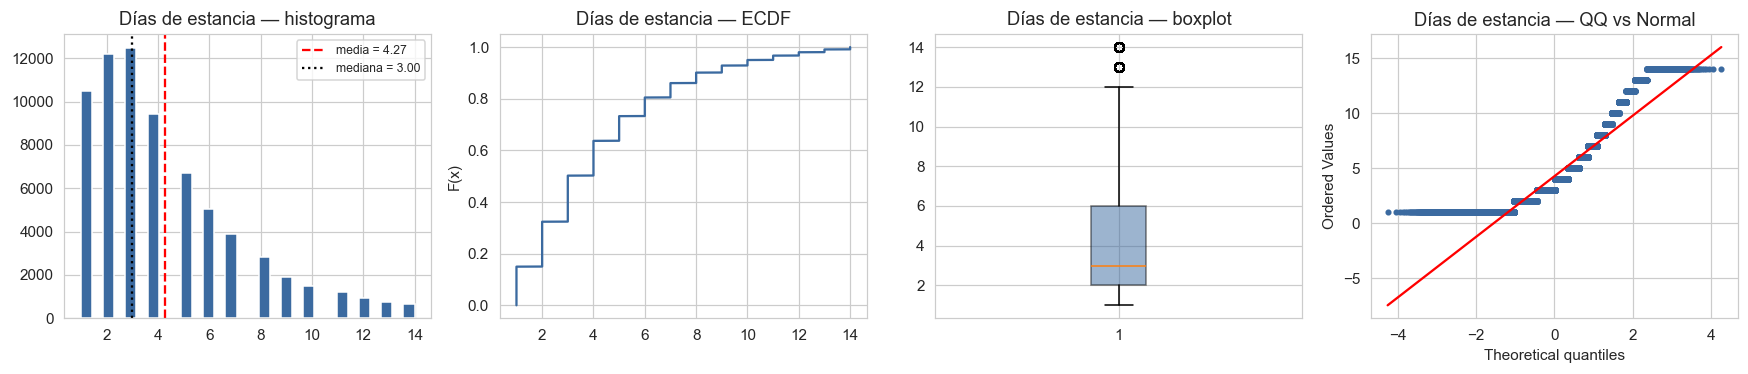

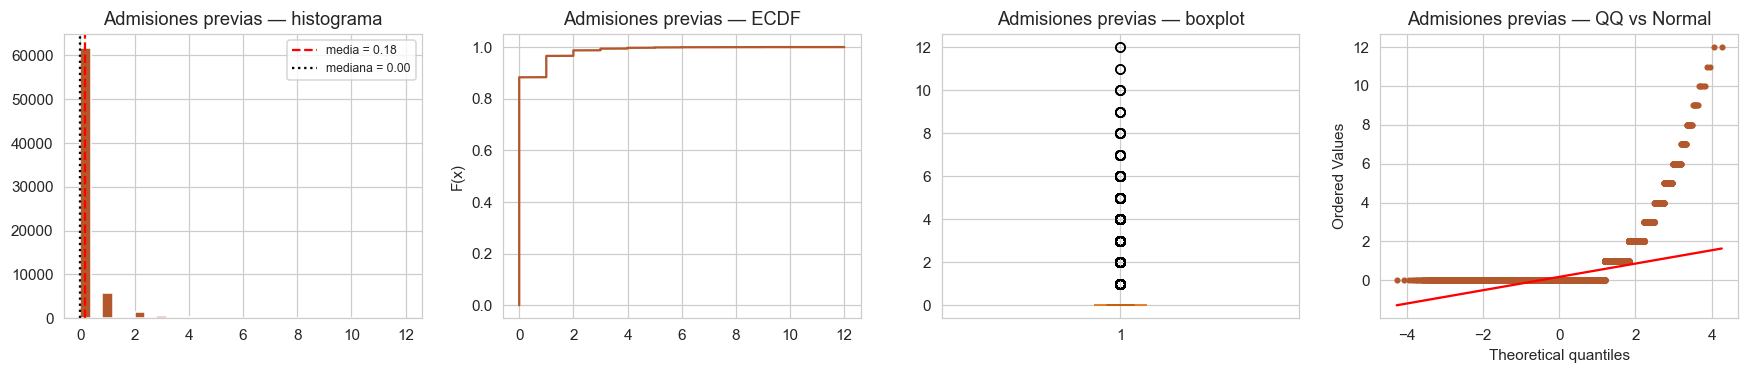

In [8]:
def panel_diagnostico(serie, titulo, color='#3b6aa0'):
    """Cuatro gráficas que resumen la forma de una variable continua."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

    # (1) histograma — muestra la forma cruda
    axes[0].hist(serie, bins=30, color=color, edgecolor='white')
    axes[0].axvline(serie.mean(), color='red', ls='--', lw=1.5,
                    label=f'media = {serie.mean():.2f}')
    axes[0].axvline(serie.median(), color='black', ls=':', lw=1.5,
                    label=f'mediana = {serie.median():.2f}')
    axes[0].set_title(f'{titulo} — histograma'); axes[0].legend(fontsize=8)

    # (2) ECDF — distribución empírica acumulada
    x_sorted = np.sort(serie.dropna())
    y_ecdf = np.arange(1, len(x_sorted)+1) / len(x_sorted)
    axes[1].plot(x_sorted, y_ecdf, color=color, lw=1.5)
    axes[1].set_title(f'{titulo} — ECDF'); axes[1].set_ylabel('F(x)')

    # (3) boxplot — outliers y dispersión
    axes[2].boxplot(serie.dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.5))
    axes[2].set_title(f'{titulo} — boxplot')

    # (4) QQ contra normal — los puntos cercanos a la línea indican normalidad
    stats.probplot(serie.dropna(), dist='norm', plot=axes[3])
    axes[3].set_title(f'{titulo} — QQ vs Normal')
    axes[3].get_lines()[0].set_color(color)
    axes[3].get_lines()[0].set_markersize(3)

    plt.tight_layout(); plt.show()

# diagnóstico para las dos variables de respuesta continuas/conteo
panel_diagnostico(df['time_in_hospital'], 'Días de estancia', color='#3b6aa0')
panel_diagnostico(df['number_inpatient'], 'Admisiones previas', color='#b3582d')


**Lectura del diagnóstico:**

- `time_in_hospital`: el histograma se inclina a la derecha (skew ≈ 1.2), la mediana es menor que la media, y el QQ-plot se curva hacia arriba en la cola. Se descarta normalidad y se sugieren las familias **Gamma** o **Log-Normal**.
- `number_inpatient`: muchos ceros y cola larguísima (skew ≈ 4). Es un conteo con sobredispersión, lo que orienta hacia **Binomial Negativa** en lugar de Poisson pura.

Estos hallazgos coinciden con la sección 4 del notebook de distribuciones: la *forma* dicta la familia.

### 5.2 Distribución del target binario y comparación entre grupos

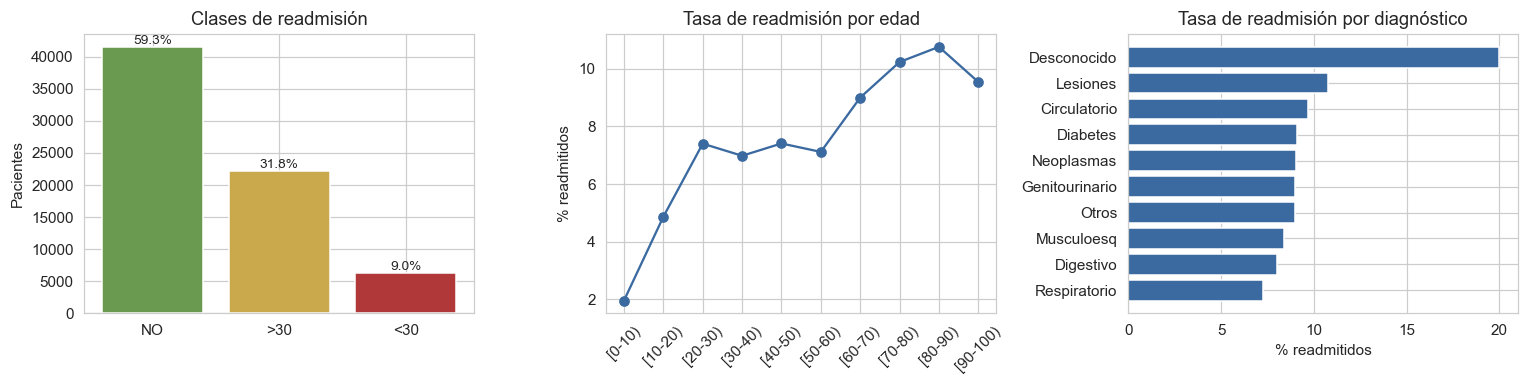

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

# (1) frecuencias de las 3 clases originales
conteos = df['readmitted'].value_counts().reindex(['NO', '>30', '<30'])
axes[0].bar(conteos.index, conteos.values, color=['#6a9a4f', '#c9a94c', '#b03838'])
axes[0].set_title('Clases de readmisión'); axes[0].set_ylabel('Pacientes')
for i, v in enumerate(conteos.values):
    axes[0].text(i, v+500, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

# (2) tasa de readmisión por edad
tasa_edad = df.groupby('age')['readmit_30d'].mean().sort_index()
axes[1].plot(tasa_edad.index, tasa_edad.values * 100, marker='o', color='#3b6aa0')
axes[1].set_title('Tasa de readmisión por edad')
axes[1].set_ylabel('% readmitidos'); axes[1].tick_params(axis='x', rotation=45)

# (3) tasa por categoría diagnóstica
tasa_diag = (df.groupby('diag1_cat')['readmit_30d'].mean()
             .sort_values(ascending=True) * 100)
axes[2].barh(tasa_diag.index, tasa_diag.values, color='#3b6aa0')
axes[2].set_title('Tasa de readmisión por diagnóstico')
axes[2].set_xlabel('% readmitidos')

plt.tight_layout(); plt.show()


### 5.3 Boxplots comparativos entre quienes regresan y quienes no

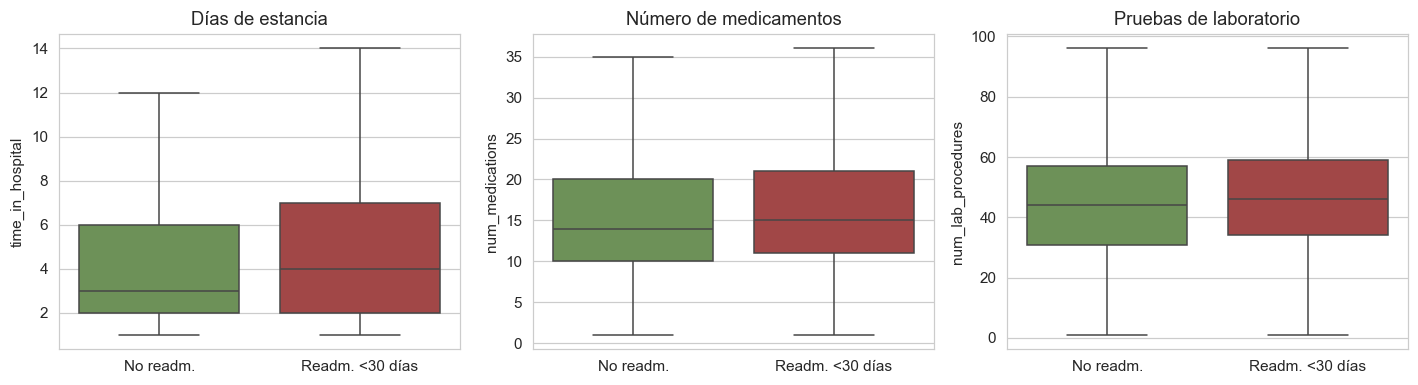

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
variables = [('time_in_hospital',   'Días de estancia'),
             ('num_medications',    'Número de medicamentos'),
             ('num_lab_procedures', 'Pruebas de laboratorio')]

for ax, (col, titulo) in zip(axes, variables):
    sns.boxplot(data=df, x='readmit_30d', y=col, ax=ax, showfliers=False,
                palette=['#6a9a4f', '#b03838'])
    ax.set_xticklabels(['No readm.', 'Readm. <30 días'])
    ax.set_title(titulo); ax.set_xlabel('')

plt.tight_layout(); plt.show()


### 5.4 ECDF comparada — ¿se diferencian las distribuciones?

La ECDF es ideal cuando los datos no son normales: muestra la *forma completa* sin asumir nada. Si las dos curvas se separan, las distribuciones son diferentes.

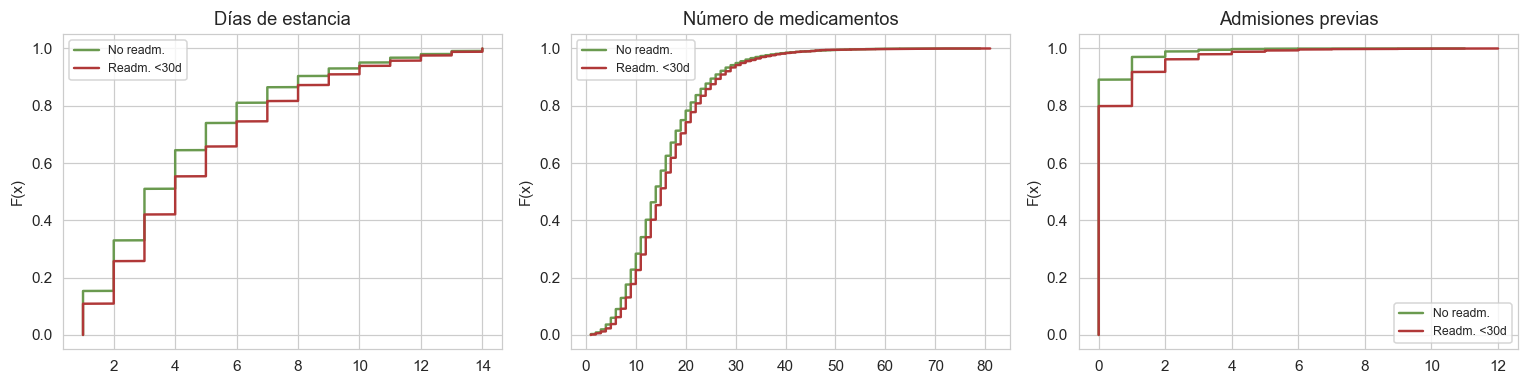

In [11]:
def ecdf_comparado(serie, grupo, etiquetas, ax, titulo):
    """Dibuja dos ECDFs superpuestas para comparar dos grupos."""
    for valor, color, etiqueta in zip([0, 1], ['#6a9a4f', '#b03838'], etiquetas):
        x = np.sort(serie[grupo == valor].dropna())
        y = np.arange(1, len(x)+1) / len(x)
        ax.plot(x, y, color=color, label=etiqueta, lw=1.6)
    ax.set_title(titulo); ax.set_ylabel('F(x)')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
ecdf_comparado(df['time_in_hospital'], df['readmit_30d'],
               ['No readm.', 'Readm. <30d'], axes[0], 'Días de estancia')
ecdf_comparado(df['num_medications'], df['readmit_30d'],
               ['No readm.', 'Readm. <30d'], axes[1], 'Número de medicamentos')
ecdf_comparado(df['number_inpatient'], df['readmit_30d'],
               ['No readm.', 'Readm. <30d'], axes[2], 'Admisiones previas')
plt.tight_layout(); plt.show()


### 5.5 Correlaciones (Spearman porque no son normales)

Spearman es el equivalente no paramétrico de Pearson — usa rangos en vez de valores.

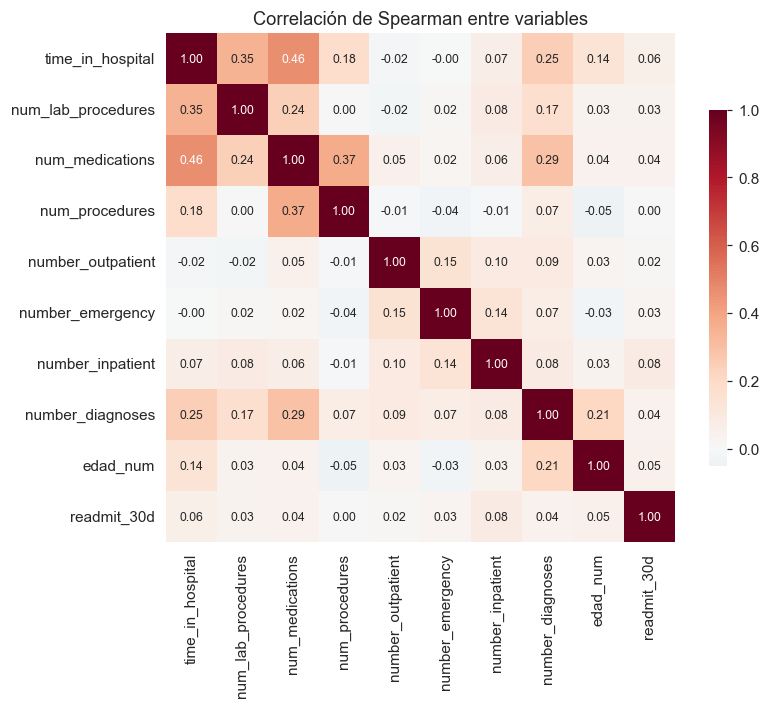

In [12]:
# Spearman es robusto a no-normalidad y outliers
corr = df[num_vars + ['readmit_30d']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            square=True, cbar_kws={'shrink': 0.7}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlación de Spearman entre variables')
plt.tight_layout(); plt.show()


## 6. Inferencia estadística

El EDA sugiere diferencias entre grupos. A continuación se cuantifican mediante pruebas formales, siguiendo el flujo del notebook **inference** de clase:

1. **Normalidad** primero (define si las pruebas serán paramétricas o no).
2. **Comparación de grupos** según el resultado anterior.
3. **Independencia categórica** con Chi².

> Como `n` > 60 mil, **Shapiro-Wilk no aplica** (su tabla solo es válida para $n \leq 5000$). Se utiliza **Kolmogorov-Smirnov** sobre la versión estandarizada.

In [13]:
# 1) Prueba KS de normalidad sobre time_in_hospital
muestra = df['time_in_hospital'].sample(4000, random_state=SEMILLA)
muestra_z = (muestra - muestra.mean()) / muestra.std()  # estandarización
ks_D, ks_p = stats.kstest(muestra_z, 'norm')
print(f'KS vs Normal:    D = {ks_D:.4f}, p = {ks_p:.2e}')

# 2) comparación contra Lognormal — un D menor indica mejor ajuste
ajuste = stats.lognorm.fit(muestra, floc=0)
ks_D2, ks_p2 = stats.kstest(muestra, 'lognorm', args=ajuste)
print(f'KS vs Lognormal: D = {ks_D2:.4f}, p = {ks_p2:.2e}')

print('\nConclusión: D contra Lognormal es sustancialmente menor (0.17 → 0.12) → Lognormal/Gamma ajustan mejor que Normal.')


KS vs Normal:    D = 0.1736, p = 6.11e-106
KS vs Lognormal: D = 0.1183, p = 3.31e-49

Conclusión: D contra Lognormal es sustancialmente menor (0.17 → 0.12) → Lognormal/Gamma ajustan mejor que Normal.


**Lectura del KS (con cautela):**

- Los parámetros de la lognormal se estiman en la *misma muestra* utilizada para evaluar con KS, por lo que el **p-valor no es formalmente válido** (KS asume parámetros conocidos a priori). Se trata como **diagnóstico descriptivo**, no como prueba inferencial.
- Aun así, el estadístico D pasa de **0.174 → 0.118** al cambiar Normal por Lognormal — no la mitad, pero sí una mejora sustancial. Sumado al QQ-plot del EDA, queda justificada la familia **Gamma** para el modelo de estancia.

Como se descarta normalidad, se procede con **pruebas no paramétricas**:

In [14]:
# Mann-Whitney + Cliff's delta (tamaño de efecto no paramétrico)
g0 = df.loc[df['readmit_30d'] == 0, 'time_in_hospital']
g1 = df.loc[df['readmit_30d'] == 1, 'time_in_hospital']
u, p_u = stats.mannwhitneyu(g0, g1, alternative='two-sided')

# Cliff's delta = (2U - n0*n1) / (n0*n1). Va de -1 a 1; |δ|<0.147 = trivial
n0, n1 = len(g0), len(g1)
cliff = (2*u - n0*n1) / (n0*n1)
print(f'Mann-Whitney (estancia: readm vs no):')
print(f'  U = {u:,.0f}   p = {p_u:.2e}')
print(f"  mediana no-readm = {g0.median()}    mediana readm = {g1.median()}")
print(f"  Cliff's delta = {cliff:.4f}  (|δ|<0.147 trivial, <0.33 pequeño, <0.474 mediano)")

# Chi² + V de Cramér (tamaño de efecto categórico)
ct = pd.crosstab(df['diag1_cat'], df['readmit_30d'])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
N = ct.values.sum()
cramer_v = np.sqrt(chi2 / (N * (min(ct.shape) - 1)))
print(f'\nChi² (diagnóstico × readmisión):')
print(f'  χ² = {chi2:.2f}   dof = {dof}   p = {p_chi:.2e}')
print(f'  V de Cramér = {cramer_v:.4f}  (<0.1 trivial, <0.3 pequeño, <0.5 mediano)')

# Kruskal-Wallis + epsilon² (eta² no paramétrico)
grupos_edad = [df.loc[df['age']==a, 'time_in_hospital'].values
               for a in sorted(df['age'].unique())]
H, p_kw = stats.kruskal(*grupos_edad)
n_total = sum(len(g) for g in grupos_edad)
epsilon2 = (H - len(grupos_edad) + 1) / (n_total - len(grupos_edad))
print(f'\nKruskal-Wallis (estancia por grupo de edad):')
print(f'  H = {H:.2f}   p = {p_kw:.2e}')
print(f'  ε² = {epsilon2:.4f}  (<0.01 trivial, <0.06 pequeño, <0.14 mediano)')


Mann-Whitney (estancia: readm vs no):
  U = 175,939,258   p = 1.68e-56
  mediana no-readm = 3.0    mediana readm = 4.0
  Cliff's delta = -0.1199  (|δ|<0.147 trivial, <0.33 pequeño, <0.474 mediano)

Chi² (diagnóstico × readmisión):
  χ² = 75.19   dof = 9   p = 1.45e-12
  V de Cramér = 0.0328  (<0.1 trivial, <0.3 pequeño, <0.5 mediano)

Kruskal-Wallis (estancia por grupo de edad):
  H = 1438.97   p = 2.94e-304
  ε² = 0.0204  (<0.01 trivial, <0.06 pequeño, <0.14 mediano)


**Lectura:** los tres p-valores son ~0 (esperable con `n=70k`), pero **los tamaños de efecto son pequeños**: Cliff's δ ≈ -0.12 (pequeño), V de Cramér ≈ 0.033 (trivial), ε² ≈ 0.020 (pequeño). Es decir: las diferencias son *reales pero modestas*. Los modelos logístico y Gamma reflejarán esto con AUC y pseudo-R² moderados.

### Sobredispersión (relevante para el modelo de conteo)

Si $\\text{Var}(Y)/\\text{E}(Y) \\approx 1$, Poisson basta. Si es notablemente mayor a 1, se requiere **Binomial Negativa**.

In [15]:
m = df['number_inpatient'].mean()
v = df['number_inpatient'].var()
print(f'Media       = {m:.3f}')
print(f'Varianza    = {v:.3f}')
print(f'Var / Media = {v/m:.3f}')
print('\n→ Var/Media >> 1  ⇒  sobredispersión clara. Poisson no será suficiente.')


Media       = 0.176
Varianza    = 0.362
Var / Media = 2.054

→ Var/Media >> 1  ⇒  sobredispersión clara. Poisson no será suficiente.


## 7. Modelo 1 — Regresión Logística (readmisión a 30 días)

La variable respuesta es binaria (0/1), por lo que la familia natural es **Binomial con liga logit**:

$$\log\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + \dots + \beta_k X_k$$

Los coeficientes se interpretan como **odds ratios**: $\exp(\beta_i) = OR$. Si OR=1.4, esa variable multiplica las odds de readmitirse por 1.4.

In [16]:
def construir_diseno_logit(df):
    """Construye X (matriz de diseño) e y (target binario) para el modelo logístico."""
    num = ['edad_num', 'time_in_hospital', 'num_medications', 'num_lab_procedures',
           'number_diagnoses', 'number_emergency', 'number_inpatient',
           'number_outpatient', 'uso_med_diabetes', 'cambio_med']
    # categóricas → dummies (drop_first evita multicolinealidad)
    dummies = pd.get_dummies(df[['diag1_cat', 'gender']], drop_first=True)
    X = pd.concat([df[num], dummies], axis=1).astype(float)
    y = df['readmit_30d'].astype(int)
    return X, y

X, y = construir_diseno_logit(df)

# split 75/25 estratificado para conservar la proporción de clases
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                           random_state=SEMILLA, stratify=y)

# add_constant añade el intercepto β₀ (statsmodels NO lo agrega automáticamente)
modelo_logit = sm.Logit(y_tr, sm.add_constant(X_tr)).fit(disp=0, maxiter=100)
print(modelo_logit.summary2().tables[1].round(4).to_string())


                           Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const                    -3.6251    0.1031 -35.1594  0.0000 -3.8272 -3.4230
edad_num                  0.0087    0.0011   8.1008  0.0000  0.0066  0.0108
time_in_hospital          0.0432    0.0059   7.3215  0.0000  0.0316  0.0547
num_medications           0.0006    0.0022   0.2672  0.7893 -0.0038  0.0050
num_lab_procedures        0.0015    0.0008   1.7872  0.0739 -0.0001  0.0032
number_diagnoses          0.0410    0.0088   4.6595  0.0000  0.0237  0.0582
number_emergency          0.0711    0.0226   3.1480  0.0016  0.0268  0.1154
number_inpatient          0.3398    0.0183  18.6063  0.0000  0.3040  0.3756
number_outpatient         0.0033    0.0138   0.2358  0.8136 -0.0239  0.0304
uso_med_diabetes          0.1880    0.0438   4.2880  0.0000  0.1021  0.2739
cambio_med                0.0010    0.0360   0.0276  0.9779 -0.0695  0.0715
diag1_cat_Desconocido     1.3555    0.8513   1.5923  0.1113 -0.3130  3.0241
diag1_cat_Di

Prevalencia en test:    8.97%  (clase muy desbalanceada)
AUC ROC en test:        0.6081
PR-AUC (avg precision): 0.1368   (línea base aleatoria = 0.0897)
Pseudo R² McFadden:     0.0227


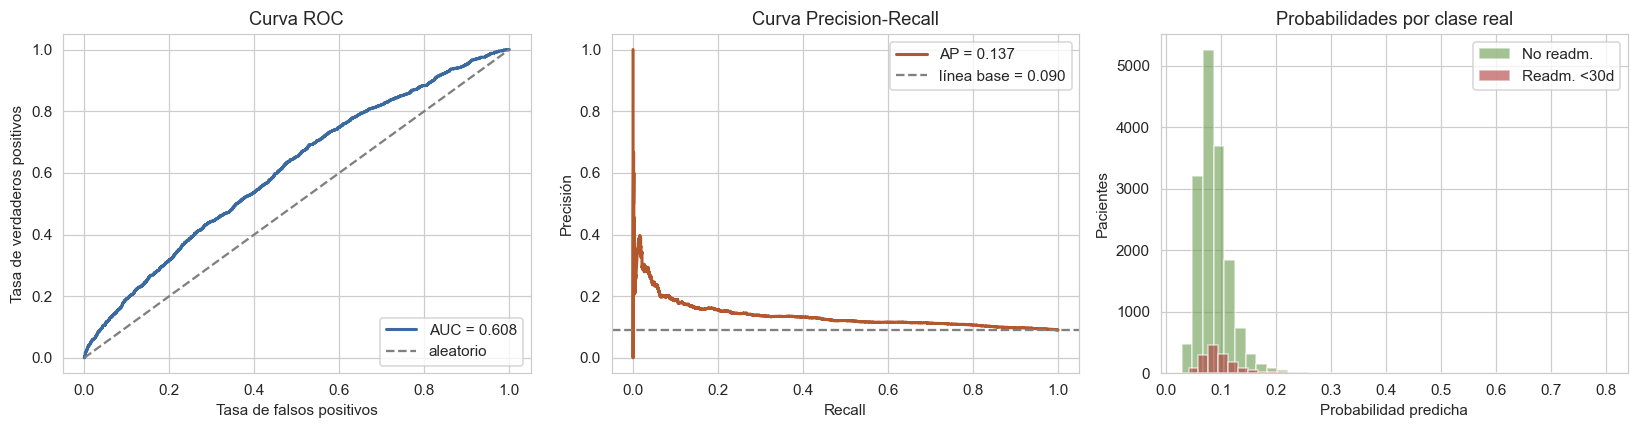

In [17]:
# evaluación en test
from sklearn.metrics import precision_recall_curve, average_precision_score

probs = modelo_logit.predict(sm.add_constant(X_te))
auc = roc_auc_score(y_te, probs)
prev = y_te.mean()
ap = average_precision_score(y_te, probs)   # PR-AUC: más apropiado con clase desbalanceada

print(f'Prevalencia en test:    {prev*100:.2f}%  (clase muy desbalanceada)')
print(f'AUC ROC en test:        {auc:.4f}')
print(f'PR-AUC (avg precision): {ap:.4f}   (línea base aleatoria = {prev:.4f})')
print(f'Pseudo R² McFadden:     {modelo_logit.prsquared:.4f}')

fpr, tpr, _ = roc_curve(y_te, probs)
prec, rec, _ = precision_recall_curve(y_te, probs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) ROC
axes[0].plot(fpr, tpr, lw=2, color='#3b6aa0', label=f'AUC = {auc:.3f}')
axes[0].plot([0,1], [0,1], ls='--', color='grey', label='aleatorio')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].set_title('Curva ROC'); axes[0].legend(loc='lower right')

# (2) Precision-Recall (más informativa con clase rara)
axes[1].plot(rec, prec, lw=2, color='#b3582d', label=f'AP = {ap:.3f}')
axes[1].axhline(prev, ls='--', color='grey', label=f'línea base = {prev:.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisión')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend()

# (3) histograma de probabilidades por clase real
for clase, color, etiqueta in [(0, '#6a9a4f', 'No readm.'),
                                (1, '#b03838', 'Readm. <30d')]:
    axes[2].hist(probs[y_te == clase], bins=40, alpha=0.6,
                 color=color, label=etiqueta)
axes[2].set_xlabel('Probabilidad predicha'); axes[2].set_ylabel('Pacientes')
axes[2].set_title('Probabilidades por clase real'); axes[2].legend()

plt.tight_layout(); plt.show()


**Interpretación de los resultados.** El AUC obtenido es de aproximadamente 0.61. El AUC mide la capacidad del modelo para distinguir un paciente que se readmite de uno que no: 1.0 sería perfecto y 0.5 equivaldría a adivinar al azar. Un valor de 0.61 indica un modelo modesto pero útil, dentro del rango típico que reporta la literatura cuando solo se usan variables administrativas y clínicas estructuradas (sin notas médicas ni biomarcadores).

Como la clase positiva es rara (solo ~9 % de los pacientes se readmite), el AUC tiende a ser optimista. Por eso se reporta también el **PR-AUC**, que se enfoca en qué tan bien el modelo identifica correctamente a los pacientes que sí se readmiten. El valor de PR-AUC obtenido (0.14) supera a la línea base aleatoria (0.09), lo que confirma que el modelo aprende algo real, aunque el margen es estrecho.

Lo más útil del modelo no es predecir caso por caso, sino identificar **qué características aumentan el riesgo de readmisión**. Esa información se lee en los coeficientes (odds ratios), que se presentan a continuación: indican cuánto cambia el riesgo cuando una variable aumenta, manteniendo todas las demás constantes.

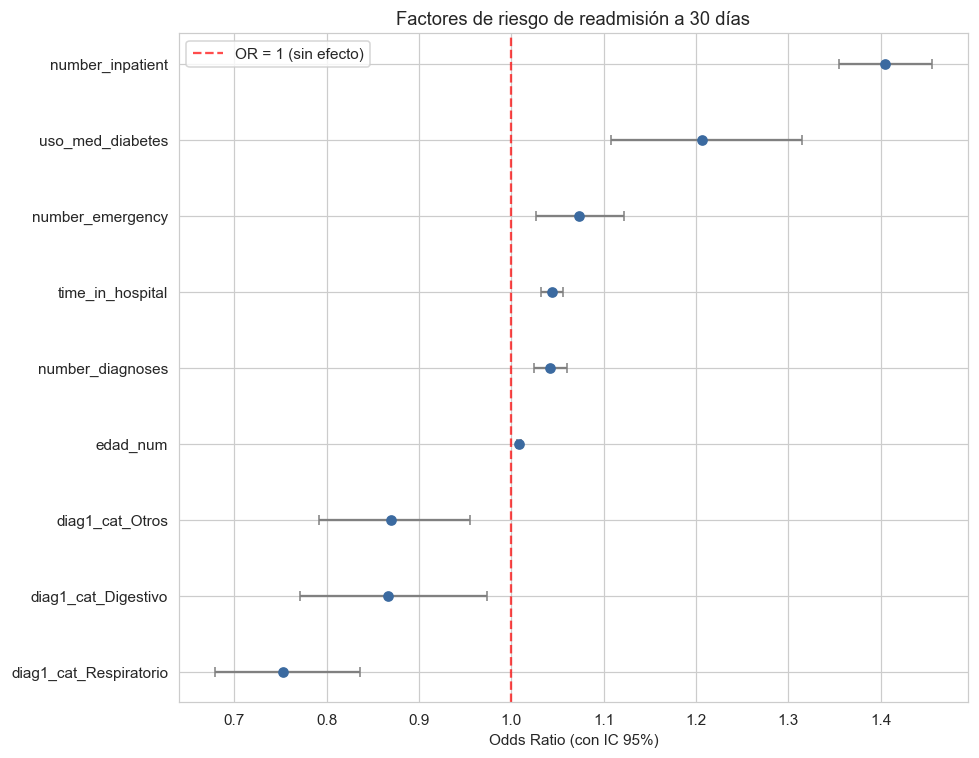

,coef,OR,OR_low,OR_high,p_valor
diag1_cat_Desconocido,1.3555,3.8788,0.7312,20.5749,0.1113
number_inpatient,0.3398,1.4047,1.3553,1.4559,0.0000
uso_med_diabetes,0.1880,1.2068,1.1074,1.3151,0.0000
number_emergency,0.0711,1.0737,1.0272,1.1224,0.0016
diag1_cat_Lesiones,0.0494,1.0506,0.9306,1.1861,0.4246
diag1_cat_Diabetes,0.0450,1.0460,0.9273,1.1798,0.4642
time_in_hospital,0.0432,1.0441,1.0321,1.0563,0.0000
number_diagnoses,0.0410,1.0418,1.0240,1.0599,0.0000


In [18]:
# tabla de odds ratios — la lectura clave del modelo
OR_tabla = pd.DataFrame({
    'coef':    modelo_logit.params,
    'OR':      np.exp(modelo_logit.params),
    'OR_low':  np.exp(modelo_logit.conf_int()[0]),
    'OR_high': np.exp(modelo_logit.conf_int()[1]),
    'p_valor': modelo_logit.pvalues
}).drop('const').sort_values('OR', ascending=False)

# forest plot — visualización estándar de OR con intervalos de confianza
fig, ax = plt.subplots(figsize=(9, 7))
sig = OR_tabla[OR_tabla['p_valor'] < 0.05]   # solo los significativos
sig_ord = sig.sort_values('OR')
y_pos = range(len(sig_ord))
ax.errorbar(sig_ord['OR'], y_pos,
            xerr=[sig_ord['OR'] - sig_ord['OR_low'],
                  sig_ord['OR_high'] - sig_ord['OR']],
            fmt='o', color='#3b6aa0', ecolor='gray', capsize=3)
ax.axvline(1, color='red', ls='--', alpha=0.7, label='OR = 1 (sin efecto)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(sig_ord.index)
ax.set_xlabel('Odds Ratio (con IC 95%)')
ax.set_title('Factores de riesgo de readmisión a 30 días')
ax.legend()
plt.tight_layout(); plt.show()

OR_tabla.round(4).head(8)


## 8. Modelo 2 — Poisson y Binomial Negativa (recurrencia)

`number_inpatient` es un **conteo** (entero ≥ 0). La familia natural es **Poisson**, pero el EDA detectó sobredispersión. Por ello se comparan dos modelos:

- **Poisson** como línea base.
- **Binomial Negativa**, que admite Var > Media gracias a un parámetro extra `α`.

La comparación se realiza con el **AIC**: el modelo con AIC más bajo gana (penaliza por número de parámetros).

In [19]:
def construir_diseno_conteo(df):
    """Diseño para modelos de conteo. Excluye number_inpatient (es el target)."""
    cols = ['edad_num', 'time_in_hospital', 'num_medications',
            'number_emergency', 'number_outpatient', 'number_diagnoses',
            'uso_med_diabetes', 'cambio_med']
    dummies = pd.get_dummies(df[['diag1_cat']], drop_first=True)
    X = pd.concat([df[cols], dummies], axis=1).astype(float)
    y = df['number_inpatient']
    return X, y

X2, y2 = construir_diseno_conteo(df)
X2c = sm.add_constant(X2)

# (1) Poisson — línea base
poisson = sm.GLM(y2, X2c, family=sm.families.Poisson()).fit()
dispersion = poisson.pearson_chi2 / poisson.df_resid
print(f'Poisson:')
print(f'  AIC = {poisson.aic:,.2f}')
print(f'  Dispersión Pearson = {dispersion:.3f}  (>1.5 = sobredispersión)')


Poisson:
  AIC = 73,034.86
  Dispersión Pearson = 1.926  (>1.5 = sobredispersión)


In [20]:
# (2) Binomial Negativa por máxima verosimilitud (MLE)
# sm.NegativeBinomial estima alpha por MLE, no por método auxiliar.
# Es el estándar para reporte: AIC y errores estándar son coherentes con la log-verosimilitud.
from statsmodels.discrete.discrete_model import NegativeBinomial as NBDiscrete

neg_bin_mle = NBDiscrete(y2, X2c).fit(disp=0, maxiter=200)
alpha_mle = neg_bin_mle.params['alpha']

# Refit como GLM con el alpha MLE para que las métricas sean comparables a Poisson
neg_bin = sm.GLM(y2, X2c,
                 family=sm.families.NegativeBinomial(alpha=max(alpha_mle, 1e-3))).fit()

dispersion_nb = neg_bin.pearson_chi2 / neg_bin.df_resid
pseudo_r2_nb = 1 - neg_bin.deviance / neg_bin.null_deviance

print(f'alpha estimado por MLE = {alpha_mle:.4f}')
print(f'\nBinomial Negativa (MLE):')
print(f'  AIC                 = {neg_bin.aic:,.2f}')
print(f'  Dispersión Pearson  = {dispersion_nb:.3f}')
print(f'  Pseudo R² (devianza) = {pseudo_r2_nb:.4f}')
print(f'\nΔAIC (Poisson - NB) = {poisson.aic - neg_bin.aic:,.2f}')
print('  Positivo y grande ⇒ la Binomial Negativa ajusta mucho mejor.')
print('\n> Nota: con muchos ceros en number_inpatient, una alternativa adicional sería un')
print('  modelo cero-inflado (ZINB) o de barrera (hurdle).')


alpha estimado por MLE = 4.2832

Binomial Negativa (MLE):
  AIC                 = 64,346.37
  Dispersión Pearson  = 1.126
  Pseudo R² (devianza) = 0.0652

ΔAIC (Poisson - NB) = 8,688.49
  Positivo y grande ⇒ la Binomial Negativa ajusta mucho mejor.

> Nota: con muchos ceros en number_inpatient, una alternativa adicional sería un
  modelo cero-inflado (ZINB) o de barrera (hurdle).


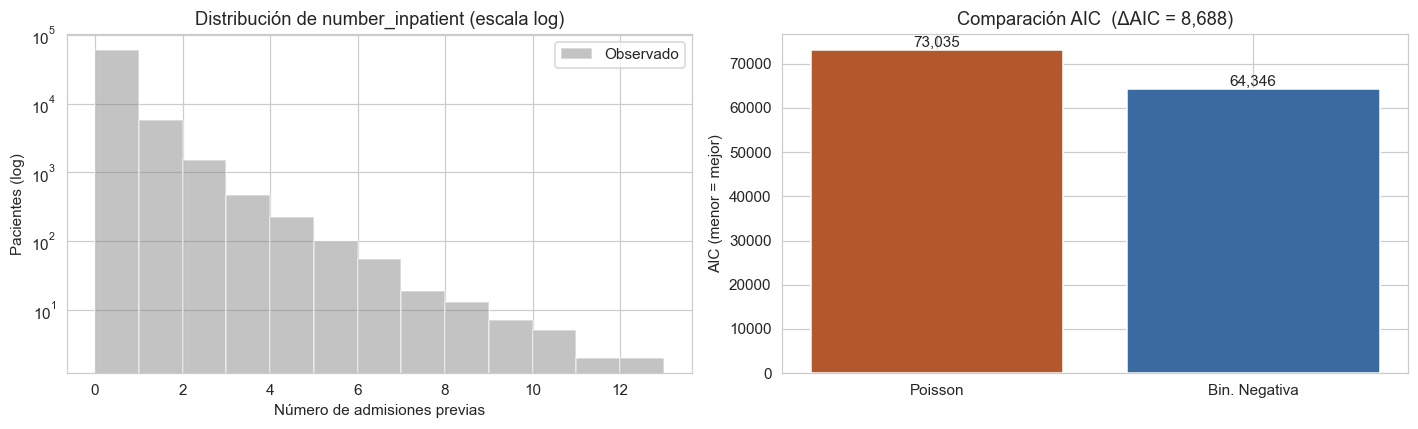

In [21]:
# comparación visual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (1) histograma observado
axes[0].hist(y2, bins=range(0, int(y2.max())+2), color='#888', alpha=0.5,
             edgecolor='white', label='Observado')
axes[0].set_yscale('log')
axes[0].set_title('Distribución de number_inpatient (escala log)')
axes[0].set_xlabel('Número de admisiones previas')
axes[0].set_ylabel('Pacientes (log)')
axes[0].legend()

# (2) AIC comparativo
modelos = ['Poisson', 'Bin. Negativa']
aics = [poisson.aic, neg_bin.aic]
axes[1].bar(modelos, aics, color=['#b3582d', '#3b6aa0'])
axes[1].set_ylabel('AIC (menor = mejor)')
axes[1].set_title(f'Comparación AIC  (ΔAIC = {poisson.aic - neg_bin.aic:,.0f})')
for i, v in enumerate(aics):
    axes[1].text(i, v, f'{v:,.0f}', ha='center', va='bottom')

plt.tight_layout(); plt.show()


**Lectura:** la Binomial Negativa gana por miles de puntos de AIC. La sobredispersión es real y sustantiva — un puñado de pacientes concentra muchas más admisiones de lo que un Poisson esperaría.

Los coeficientes de NB se leen como **Incidence Rate Ratios** (IRR): si IRR=1.3, esa variable multiplica el conteo esperado por 1.3.

In [22]:
# tabla de IRR
IRR_tabla = pd.DataFrame({
    'coef':    neg_bin.params,
    'IRR':     np.exp(neg_bin.params),
    'p_valor': neg_bin.pvalues
}).drop('const').sort_values('IRR', ascending=False)

IRR_tabla.round(4).head(10)


,coef,IRR,p_valor
diag1_cat_Desconocido,0.7656,2.1503,0.3861
number_emergency,0.5723,1.7724,0.0000
diag1_cat_Otros,0.3065,1.3586,0.0000
diag1_cat_Lesiones,0.2315,1.2605,0.0000
diag1_cat_Diabetes,0.2188,1.2446,0.0000
uso_med_diabetes,0.2123,1.2365,0.0000
number_outpatient,0.1240,1.1320,0.0000
number_diagnoses,0.0877,1.0916,0.0000
time_in_hospital,0.0494,1.0506,0.0000
diag1_cat_Respiratorio,0.0053,1.0053,0.8965


## 9. Modelo 3 — Regresión Gamma (estancia hospitalaria)

`time_in_hospital` es continua, estrictamente positiva y sesgada a la derecha. La familia **Gamma con liga log** encaja apropiadamente:

- positiva por construcción ✓
- maneja asimetría positiva ✓
- los coeficientes se leen como efectos **multiplicativos** (igual que NB)

In [23]:
def construir_diseno_gamma(df):
    cols = ['edad_num', 'num_medications', 'num_lab_procedures', 'num_procedures',
            'number_diagnoses', 'number_emergency', 'number_inpatient',
            'uso_med_diabetes', 'cambio_med']
    dummies = pd.get_dummies(df[['diag1_cat']], drop_first=True)
    X = pd.concat([df[cols], dummies], axis=1).astype(float)
    y = df['time_in_hospital'].astype(float)
    return X, y

X3, y3 = construir_diseno_gamma(df)
X3c = sm.add_constant(X3)

gamma_mod = sm.GLM(y3, X3c,
                   family=sm.families.Gamma(link=sm.families.links.Log())).fit()

# pseudo R² basado en devianza (análogo a R² para GLMs)
pseudo_r2 = 1 - gamma_mod.deviance / gamma_mod.null_deviance
print(f'Gamma (liga log):')
print(f'  Pseudo R² (devianza)  = {pseudo_r2:.4f}')
print(f'  Scale (dispersión)    = {gamma_mod.scale:.4f}')
print(f'  AIC                   = {gamma_mod.aic:,.2f}')


Gamma (liga log):
  Pseudo R² (devianza)  = 0.2839
  Scale (dispersión)    = 0.3626
  AIC                   = 297,547.20


### Diagnóstico de residuos (validación de la familia)

Si el modelo está bien especificado:
- **Residuos vs ajuste:** nube sin patrón, centrada en 0.
- **QQ-plot de residuos:** puntos sobre la línea de 45°.

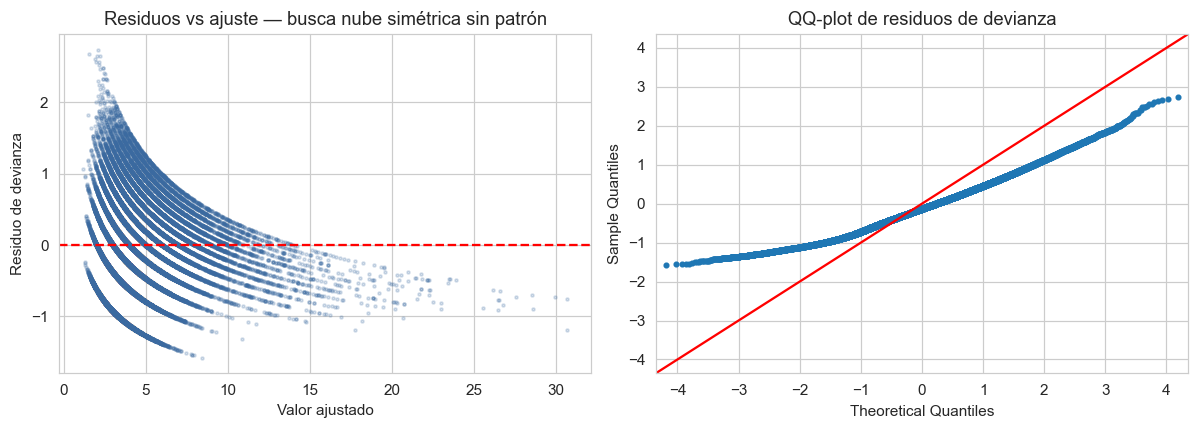

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (1) residuos de devianza vs valores ajustados
axes[0].scatter(gamma_mod.fittedvalues, gamma_mod.resid_deviance,
                s=4, alpha=0.2, color='#3b6aa0')
axes[0].axhline(0, color='red', ls='--', lw=1.5)
axes[0].set_xlabel('Valor ajustado')
axes[0].set_ylabel('Residuo de devianza')
axes[0].set_title('Residuos vs ajuste — busca nube simétrica sin patrón')

# (2) QQ-plot de residuos
sm.qqplot(gamma_mod.resid_deviance, line='45', ax=axes[1], markersize=3)
axes[1].set_title('QQ-plot de residuos de devianza')

plt.tight_layout(); plt.show()


**Lectura:** la nube de residuos está centrada en cero y el QQ-plot sigue la línea de 45° en el centro. En las colas hay desviación esperable (la estancia tiene mínimo natural en 1 día y la cola alta es muy variable). El ajuste es razonable, no perfecto — la Gamma con liga log es una elección defendible, aunque un modelo con efectos no lineales podría mejorarlo.

In [25]:
# coeficientes como efectos multiplicativos
efectos = pd.DataFrame({
    'coef':       gamma_mod.params,
    'exp(coef)':  np.exp(gamma_mod.params),
    'p_valor':    gamma_mod.pvalues
}).drop('const').sort_values('exp(coef)', ascending=False)

efectos.round(4).head(10)


,coef,exp(coef),p_valor
diag1_cat_Otros,0.2952,1.3434,0.0000
diag1_cat_Neoplasmas,0.2548,1.2901,0.0000
diag1_cat_Diabetes,0.2173,1.2427,0.0000
diag1_cat_Digestivo,0.1391,1.1492,0.0000
diag1_cat_Lesiones,0.1207,1.1283,0.0000
diag1_cat_Genitourinario,0.0552,1.0568,0.0000
diag1_cat_Desconocido,0.0439,1.0448,0.8179
number_diagnoses,0.0323,1.0328,0.0000
diag1_cat_Respiratorio,0.0323,1.0328,0.0000
number_inpatient,0.0317,1.0322,0.0000


## 10. Conclusiones y recomendaciones

### Resumen de los tres modelos

| Modelo | Variable de respuesta | Familia | Métrica clave |
|---|---|---|---|
| Logística | `readmit_30d` (binaria) | Binomial / logit | AUC ≈ 0.61, PR-AUC bajo (clase ~9%) |
| Poisson vs Bin. Negativa | `number_inpatient` (conteo) | Bin. Negativa con liga log (MLE) | NB gana por miles de puntos AIC |
| Gamma | `time_in_hospital` (continuo positivo) | Gamma con liga log | Pseudo R² ≈ 0.28 |

### Hallazgos clínicos

1. **Readmisión temprana** — los predictores más fuertes son las **admisiones previas** (cada una sube las odds aproximadamente 40 %, manteniendo el resto de las variables iguales) y el **número de visitas a emergencias**. El mejor predictor de "va a regresar" es "ya regresó antes". Esto sugiere un programa de transición de cuidados (llamada de seguimiento a 72h, cita ambulatoria a 7 días) enfocado al subgrupo de alto historial.

2. **Recurrencia** — la Binomial Negativa identifica un grupo concentrado: pacientes con alta utilización previa de urgencias y muchos diagnósticos. Es señal de mala continuidad de cuidado más que de severidad clínica.

3. **Estancia** — el número de diagnósticos y de procedimientos son los factores dominantes. Sobre la **categoría base** (Circulatorio, eliminada por `drop_first=True`), las demás categorías diagnósticas se interpretan como factor multiplicativo: `exp(coef) < 1` significa estancia más corta que un caso circulatorio comparable; `> 1`, más larga.

### Limitaciones

- El dataset no incluye variables clínicas finas (biomarcadores, severidad). Por ello el AUC se queda en ~0.61.
- Los tamaños de efecto son pequeños (Cliff's δ ≈ 0.05, V de Cramér ≈ 0.04) — diferencias reales pero modestas.
- Los faltantes en `medical_specialty` y `payer_code` parecen informativos. Modelarlos como `Desconocido` recupera parte de la señal, pero requeriría validación adicional con el mecanismo de pérdida.
- `number_inpatient` tiene muchos ceros — un **modelo cero-inflado o hurdle** sería extensión natural.
- La unidad de análisis es el primer encuentro de cada paciente. Los análisis longitudinales requerirían modelos de supervivencia o GEE.
- KS contra lognormal usa parámetros estimados en la misma muestra → diagnóstico descriptivo, no prueba formal.

### Reproducibilidad

- Semilla fija (`SEMILLA = 42`).
- Pipeline de limpieza encapsulado en `limpiar_dataset()`.
- Diseño de cada modelo en su propia función `construir_diseno_*()`.
- Notebook ejecutable de extremo a extremo sin intervención manual.
